In [73]:
#Análise Estatística

In [1]:
import pandas as pd
import numpy as np

In [2]:
# 1. Carregar o dataset
srp = pd.read_csv("./DATASET/survey_results_public.csv")

# 2. Lista de valores inválidos
valores_invalidos = ['?', 'n.a', 'n.a.', 'NA', 'na', 'N/A']

# 3. Substituir esses valores por NaN
srp = srp.replace(valores_invalidos, np.nan)

# 4. Criar 3 cópias do dataset original
dataset_media = srp.copy()
dataset_mediana = srp.copy()
dataset_zero = srp.copy()

# 5. Selecionar apenas colunas numéricas
colunas_numericas = srp.select_dtypes(include=[np.number]).columns

# 6. Preencher valores em falta nas colunas numéricas
for col in colunas_numericas:
    dataset_media[col] = dataset_media[col].fillna(dataset_media[col].mean())
    dataset_mediana[col] = dataset_mediana[col].fillna(dataset_mediana[col].median())
    dataset_zero[col] = dataset_zero[col].fillna(0)

# 7. Se quiseres também tratar colunas de texto, podes preencher com "Sem dado"
colunas_texto = srp.select_dtypes(include=["object"]).columns

for col in colunas_texto:
    dataset_media[col] = dataset_media[col].fillna("Sem dado")
    dataset_mediana[col] = dataset_mediana[col].fillna("Sem dado")
    dataset_zero[col] = dataset_zero[col].fillna("Sem dado")

# 8. Guardar os 3 novos datasets em ficheiros CSV
dataset_media.to_csv("./DATASET/dataset_limpo_media.csv", index=False)
dataset_mediana.to_csv("./DATASET/dataset_limpo_mediana.csv", index=False)
dataset_zero.to_csv("./DATASET/dataset_limpo_zero.csv", index=False)

print("Os 3 ficheiros foram criados com sucesso na pasta DATASET.")

Os 3 ficheiros foram criados com sucesso na pasta DATASET.


In [3]:
dataset_media.isna().sum()

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64

In [4]:
dataset_mediana.isna().sum()

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64

In [5]:
dataset_zero.isna().sum()

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64

In [6]:
dataset_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [7]:
dataset_mediana.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [8]:
dataset_media.compare(dataset_mediana)

CompTotal              WorkExp       JobSatPoints_1        \
                self     other       self other           self other   
0      2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
1      2.963841e+145  110000.0        NaN   NaN            NaN   NaN   
2      2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
3      2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
4      2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
...              ...       ...        ...   ...            ...   ...   
65432  2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
65433  2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
65434  2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   
65435  2.963841e+145  110000.0        NaN   NaN            NaN   NaN   
65436  2.963841e+145  110000.0  11.466957   9.0      18.581094  10.0   

      JobSatPoints_4       JobSatPoints_5        ... JobSatPoints_9        \
                self other           self other  ...           self other   
0            7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
1                NaN   NaN            NaN   NaN  ...            NaN   NaN   
2            7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
3            7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
4            7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
...              ...   ...            ...   ...  ...            ...   ...   
65432        7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
65433        7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
65434        7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   
65435            NaN   NaN            NaN   NaN  ...            NaN   NaN   
65436        7.52214   0.0      10.060857   0.0  ...      16.169432   5.0   

      JobSatPoints_10       JobSatPoints_11       ConvertedCompYearly  \
                 self other            self other                self   
0           10.955713   0.0        9.953948   0.0        86155.287263   
1                 NaN   NaN             NaN   NaN        86155.287263   
2           10.955713   0.0        9.953948   0.0        86155.287263   
3           10.955713   0.0        9.953948   0.0        86155.287263   
4           10.955713   0.0        9.953948   0.0        86155.287263   
...               ...   ...             ...   ...                 ...   
65432       10.955713   0.0        9.953948   0.0        86155.287263   
65433       10.955713   0.0        9.953948   0.0        86155.287263   
65434       10.955713   0.0        9.953948   0.0        86155.287263   
65435             NaN   NaN             NaN   NaN        86155.287263   
65436       10.955713   0.0        9.953948   0.0        86155.287263   

                  JobSat        
         other      self other  
0      65000.0  6.935041   7.0  
1      65000.0  6.935041   7.0  
2      65000.0  6.935041   7.0  
3      65000.0  6.935041   7.0  
4      65000.0  6.935041   7.0  
...        ...       ...   ...  
65432  65000.0  6.935041   7.0  
65433  65000.0  6.935041   7.0  
65434  65000.0  6.935041   7.0  
65435  65000.0  6.935041   7.0  
65436  65000.0  6.935041   7.0  

[49642 rows x 26 columns]

In [9]:
dataset_media.isna().sum().sum()

np.int64(0)

In [10]:
dataset_mediana.isna().sum().sum()

np.int64(0)

In [11]:
dataset_media.isna().sum().sort_values(ascending=False)

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64

In [12]:
# 1. Carregar o dataset limpo (com zero)
srp = pd.read_csv('DATASET/dataset_limpo_mediana.csv')
#LIMPEZA: Transformar o texto em intervalos simples
# Removemos "years old", "Under", etc.
srp['Age'] = (srp['Age']
             .str.replace(' years old', '', regex=False)
             .str.replace('Under ', '<', regex=False)
             .str.replace(' years or older', '+', regex=False))

In [13]:
# CRIAR A VARIÁVEL NUMÉRICA DE GAMAS (Age_Code)
# A professora sugeriu isto para que a variável seja tratada como um "valor"
# Atribuímos um peso de 1 a 7 para cada faixa etária
map_num = {
    '<18': 1, 
    '18-24': 2, 
    '25-34': 3, 
    '35-44': 4, 
    '45-54': 5, 
    '55-64': 6, 
    '65+': 7,
    'Prefer not to say': 0  # Atribuímos 0 para quem não quis dizer
}
srp['Age_Code'] = srp['Age'].map(map_num)
srp['Age_Code'] = srp['Age_Code'].astype(int)

In [14]:
# CRIAÇÃO DA VARIÁVEL DE GERAÇÕES (Variável qualitativa)
map_gen = {
    '<18': 'Gen Alpha', 
    '18-24': 'Gen Z', 
    '25-34': 'Millennials', 
    '35-44': 'Millennials/Gen X', 
    '45-54': 'Gen X', 
    '55-64': 'Boomers', 
    '65+': 'Silent Generation',
    'Prefer not to say': 'Não Declarado'
}
srp['Geração'] = srp['Age'].map(map_gen)

In [15]:
# VERIFICAÇÃO
print("Novas variáveis criadas com sucesso:")
print(srp[['Age', 'Age_Code', 'Geração']].head(10))

Novas variáveis criadas com sucesso:
     Age  Age_Code            Geração
0    <18         1          Gen Alpha
1  35-44         4  Millennials/Gen X
2  45-54         5              Gen X
3  18-24         2              Gen Z
4  18-24         2              Gen Z
5    <18         1          Gen Alpha
6  35-44         4  Millennials/Gen X
7  18-24         2              Gen Z
8  45-54         5              Gen X
9  35-44         4  Millennials/Gen X


In [16]:
# Mostrar a contagem de nulos em todas as colunas (foi apenas uma validação para garantir que não há mais nulos)
print(srp.isnull().sum())

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Age_Code               0
Geração                0
Length: 116, dtype: int64


In [17]:
#SALVAR NUMA NOVA CÓPIA (Juntei o meu trabalho com o dataset limpo zero do Luís)
srp.to_csv('DATASET/dataset_limpo_medianag.csv', index=False)

In [18]:
#1º chamamos o nosso dataset limpo e com as novas colunas das gerações
#2º  escolhemos as variáveis (colunas) que vamos usar na nossa análise estatística - apenas colunas numéricas
#3º Verificamos qual o nome das nossas colunas 
#4º Vemos também qual a dimensão do nosso novo dataset numérico

dataset_medianag = pd.read_csv("./DATASET/dataset_limpo_medianag.csv")
data = dataset_medianag.select_dtypes(include="number")


print("Colunas numéricas:")
print(data.columns)

print("\nDimensão do dataset numérico:")
print(data.shape)

Colunas numéricas:
Index(['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1',
       'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7',
       'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'Age_Code'],
      dtype='object')

Dimensão do dataset numérico:
(65437, 15)


In [19]:
#Vamos usar o describe para verificar as principais estatisticas - média, max. min...

print("ESTATÍSTICAS DESCRITIVAS GERAIS")
display(data.describe())

ESTATÍSTICAS DESCRITIVAS GERAIS


,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat,Age_Code
count,65437.000000,6.543700e+04,65437.000000,65437.000000,65437.000000,65437.000000,65437.000000,65437.000000,65437.000000,65437.000000,65437.000000,65437.000000,6.543700e+04,65437.000000,65437.000000
mean,32719.000000,1.528187e+145,10.118098,13.845409,3.378796,4.521905,21.954677,18.584513,14.626643,10.027841,4.930632,4.479026,7.257636e+04,6.971087,3.275884
std,18890.179119,3.909204e+147,6.293516,17.898368,12.901399,15.469507,18.300966,18.552441,18.247594,17.570898,16.304722,15.423596,1.122207e+05,1.393560,1.222237
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000
25%,16360.000000,1.030000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.000000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000,2.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.000000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000,3.000000
75%,49078.000000,1.140000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.000000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000,4.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000,7.000000


In [20]:
#De seguida fazemos os cáclculo dos quartis e cálculamos também o IQR (mostra onde está concetrada a maioria dos dados)

quartis = pd.DataFrame({
    "Q1 (25%)": data.quantile(0.25),
    "Q2 (50% / Mediana)": data.quantile(0.50),
    "Q3 (75%)": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25)
})

quartis

,Q1 (25%),Q2 (50% / Mediana),Q3 (75%),IQR
ResponseId,16360.0,32719.0,49078.0,32718.0
CompTotal,103000.0,110000.0,114000.0,11000.0
WorkExp,9.0,9.0,9.0,0.0
JobSatPoints_1,10.0,10.0,10.0,0.0
JobSatPoints_4,0.0,0.0,0.0,0.0
JobSatPoints_5,0.0,0.0,0.0,0.0
JobSatPoints_6,20.0,20.0,20.0,0.0
JobSatPoints_7,15.0,15.0,15.0,0.0
JobSatPoints_8,10.0,10.0,10.0,0.0
JobSatPoints_9,5.0,5.0,5.0,0.0


In [21]:
#Através da covariancia, conseguimos visualizar como as duas variaveis variam em conjunto.
#NEste caso, vemos um valor positivo o que seignifica que tendem a aumentar juntas, logo
#Quanto mais experiencia, melhor é o salário

covariancia = data[["WorkExp", "ConvertedCompYearly"]].cov()
covariancia

,WorkExp,ConvertedCompYearly
WorkExp,39.608340,6.048068e+04
ConvertedCompYearly,60480.678865,1.259348e+10


In [22]:
#Com a correlação conseguimos verificar o grau de relação entre duas variáveis.
#Neste caso a correlação é bastante baixa, cerca de 0.086, ou seja, quase não existe correlação entre a Experienci de trabalho e o salário anual convertido

corr = data[["WorkExp", "ConvertedCompYearly"]].corr()
corr

,WorkExp,ConvertedCompYearly
WorkExp,1.000000,0.085635
ConvertedCompYearly,0.085635,1.000000


In [23]:
#Neste caso já é diferente, aqui já conseguimos identificar uma correlação de 0.48, o que significa que é Moderada.
#Ou seja, a Experiencia tem alguma coisa a ver com os Anos de Código
corrB = data[['WorkExp', 'Age_Code']].corr()
corrB

,WorkExp,Age_Code
WorkExp,1.000000,0.475688
Age_Code,0.475688,1.000000


In [24]:
#Converter a variavel para numérico, todos os registos que contivesse:
#Sem dado - passa a ser 0 (ou seja, nada)
#Se disser - Less than 1 year, passa a 0.5 e
#Se disser - more than 50 year, passa a 50

dataset_medianag["YearsCode"] = dataset_medianag["YearsCode"].replace({
    "Sem dado": 0,
    "Less than 1 year": 0.5,
    "More than 50 years": 50
})

dataset_medianag["YearsCode"] = pd.to_numeric(dataset_medianag["YearsCode"])

In [25]:
#Fazemos o mesmo que o anterior, mas para a variável YearsCodePro

dataset_medianag["YearsCodePro"] = dataset_medianag["YearsCodePro"].replace({
    "Sem dado": 0,
    "Less than 1 year": 0.5,
    "More than 50 years": 50
})

dataset_medianag["YearsCodePro"] = pd.to_numeric(dataset_medianag["YearsCodePro"])

In [26]:
#Verificamos novamente quais as colunas que estão como numérico

data = dataset_medianag.select_dtypes(include="number")
data.columns

Index(['ResponseId', 'YearsCode', 'YearsCodePro', 'CompTotal', 'WorkExp',
       'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6',
       'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'Age_Code'],
      dtype='object')

In [27]:
#Correlações Especificas


In [28]:
#Experiência Profissional vs Anos de Código

corr_A = data[["WorkExp", "YearsCode"]].corr()
corr_A

#Verificamos então que existe uma correlação moderada entre estas duas variáveis.

,WorkExp,YearsCode
WorkExp,1.000000,0.546866
YearsCode,0.546866,1.000000


In [29]:
#Experiência profissional vs Anos de Código Profissional
corr_B = data[["WorkExp", "YearsCodePro"]].corr()
corr_B

##Verificamos então que existe uma correlação moderada entre estas duas variáveis. E é uma correlação um pouco mais forte que a anterior

,WorkExp,YearsCodePro
WorkExp,1.000000,0.585508
YearsCodePro,0.585508,1.000000


In [30]:
#Satisfação no trabalho vs Salário Anual
corr_C = data[["JobSat", "ConvertedCompYearly"]].corr()
corr_C

#Correlação muito baixa, quase inexistente

,JobSat,ConvertedCompYearly
JobSat,1.000000,0.026164
ConvertedCompYearly,0.026164,1.000000


In [31]:
#Satisfação no trabalho vs experiência
corr_D = data[["JobSat", "WorkExp"]].corr()
corr_D

##Correlação muito baixa, quase inexistente

,JobSat,WorkExp
JobSat,1.000000,0.090001
WorkExp,0.090001,1.000000


In [32]:
percentis = pd.DataFrame({
    "WorkExp": data["WorkExp"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]),
    "ConvertedCompYearly": data["ConvertedCompYearly"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]),
    "YearsCode": data["YearsCode"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]),
    "YearsCodePro": data["YearsCodePro"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
})
percentis

#Anos de Experiencia:
    #10% dos developers têm até 4 anos de experiência
    #50% (mediana) têm cerca de 9 anos
    #90% têm até 17 anos, ou seja, A maioria dos developers do dataset tem entre 4 e 17 anos de experiência.

#Salário Anual
    #10% ganham até 37592 USD
    #50% (mediana) ganham 65000 USD
    #90% ganham até 101910 USD, ou seja, o salário típico dos developers está perto de 65000 USD.

#Anos a Programar
    #10% têm 1 ano de experiência em programação
    #50% têm cerca de 10 anos
    #90% têm até 30 anos, ou seja, muitos developers começam a programar antes da carreira profissional.

#Anos a programar profissionalmente
    #10% têm 0 anos
    #50% têm 5 anos
    #90% têm 21 anos, ou seja, conseguimos ver que existe una grande diferença entre os Anos de código e os anos de codio profissional

,WorkExp,ConvertedCompYearly,YearsCode,YearsCodePro
0.10,4.0,37592.0,1.0,0.0
0.25,9.0,65000.0,5.0,0.5
0.50,9.0,65000.0,10.0,5.0
0.75,9.0,65000.0,18.0,12.0
0.90,17.0,101910.0,30.0,21.0


In [33]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()

outliers_data = pd.DataFrame({
    "Número de Outliers": outliers,
    "Percentagem de Outliers (%)": (outliers / len(data)) * 100
})

outliers_data.sort_values(by="Número de Outliers", ascending=False)

,Número de Outliers,Percentagem de Outliers (%)
WorkExp,28676,43.822302
CompTotal,28132,42.990968
JobSatPoints_7,27847,42.555435
JobSatPoints_9,27569,42.130599
JobSatPoints_8,25844,39.494476
JobSatPoints_1,25314,38.684536
JobSatPoints_6,25098,38.354448
ConvertedCompYearly,23398,35.756529
JobSat,22747,34.761679
JobSatPoints_10,12121,18.523160


In [ ]:
#EM primeiro lugar cálculamos os quartis (Q1 e Q2), para depois conseguirmos calcular o IQR (para ver onde os dados estavam concetrados).
#O valor é considerado um outlier se estiver abaixo de Q1 - 1.5 * IQR ou acima de Q3 + 1.5 * IQR
#Com os resultados conseguimos ver que as variaveis que estão relacionadas a experiencia ou salário tem um maior número de outliers, 
#isso pode ser explicado porque existe uma grande variedade no mercado de trabalho, de diferentes países, niveis de experiencia...

In [ ]:
print("TOP 10 MAIORES SALÁRIOS")
display(data[["WorkExp", "YearsCode", "YearsCodePro", "ConvertedCompYearly", "Age_Code", "JobSat"]]
        .sort_values(by="ConvertedCompYearly", ascending=False)
        .head(10))

#Aqui conseguimos visualizar quais os 10 funcionários que possuem o maior salário.
#Vemos também que os anos de experiência não signifca que se tenha um salário maior, por exemplo:
        #o 12723 tem 4 anos de experiência e ganha 13 818 022 enquanto que o 13763 tem 12 anos de experiência e ganha apenas 2 048 046

TOP 10 MAIORES SALÁRIOS


,WorkExp,YearsCode,YearsCodePro,ConvertedCompYearly,Age_Code,JobSat
15837,9.0,16.0,5.0,16256603.0,3,7.0
12723,4.0,5.0,10.0,13818022.0,3,10.0
28379,15.0,15.0,7.0,9000000.0,2,10.0
17593,13.0,16.0,13.0,6340564.0,4,6.0
17672,11.0,16.0,11.0,4936778.0,3,7.0
19267,7.0,13.0,7.0,3367716.0,3,7.0
23694,9.0,9.0,5.0,2584118.0,2,7.0
33720,9.0,9.0,5.0,2237846.0,3,7.0
34523,2.0,6.0,2.0,2153432.0,2,10.0
13763,12.0,15.0,12.0,2048046.0,4,10.0


In [ ]:
print("TOP 10 MENORES SALÁRIOS")

display(
    data[data["ConvertedCompYearly"] > 5000][["WorkExp", "YearsCode", "YearsCodePro", "ConvertedCompYearly", "Age_Code", "JobSat"]]
    .sort_values(by="ConvertedCompYearly", ascending=True)
    .head(10)
)

#Aqui é a mesma coisa que em cima, mas os 10 funcionários que ganahm menos. 
#Colocamos > 5000, porque se não colocarmos nada o dataset vai buscar os menores que no caso tem como salário 1
#Isso não significa que eles ganham 1 dolar por ano, isso pode acontecer por:

    #erros de preenchimento (dados incompletos)
    #o utilizador colocou apenas valores baixos, para despachar o questionário

TOP 10 MENORES SALÁRIOS


,WorkExp,YearsCode,YearsCodePro,ConvertedCompYearly,Age_Code,JobSat
12171,1.0,2.0,1.0,5025.0,3,5.0
18816,2.0,7.0,2.0,5025.0,3,6.0
5021,1.0,4.0,1.0,5025.0,2,7.0
11252,0.0,6.0,0.5,5025.0,3,6.0
35971,2.0,5.0,1.0,5025.0,3,6.0
20682,4.0,13.0,3.0,5025.0,3,7.0
39229,2.0,7.0,2.0,5025.0,3,5.0
2967,2.0,4.0,2.0,5025.0,2,3.0
12045,2.0,4.0,1.0,5025.0,2,7.0
28553,9.0,5.0,9.0,5051.0,3,7.0


In [37]:
print("TOP 10 MENORES SALÁRIOS")

display(data[["WorkExp","YearsCode","YearsCodePro","ConvertedCompYearly","Age_Code","JobSat"]]
        .sort_values(by="ConvertedCompYearly", ascending=True)
        .head(10))

TOP 10 MENORES SALÁRIOS


,WorkExp,YearsCode,YearsCodePro,ConvertedCompYearly,Age_Code,JobSat
36370,12.0,13.0,11.0,1.0,4,1.0
36310,5.0,5.0,1.0,1.0,3,7.0
26673,10.0,10.0,10.0,1.0,3,6.0
3890,9.0,13.0,6.0,1.0,3,7.0
25200,17.0,0.0,0.0,1.0,2,10.0
20888,5.0,10.0,6.0,1.0,3,8.0
10678,10.0,15.0,10.0,1.0,4,7.0
24247,5.0,5.0,5.0,1.0,4,4.0
30935,30.0,3.0,2.0,1.0,5,6.0
6963,26.0,23.0,18.0,1.0,4,10.0


In [ ]:
#ANÀLISE CRITICA

#A análise estatística realizada sobre o dataset Stack Overflow Developer Survey 2024 permitiu identificar padrões relevantes relacionados 
#com a experiência profissional, anos de programação, satisfação no trabalho e remuneração. No entanto, a interpretação destes resultados 
#deve ser feita de forma crítica, tendo em conta tanto as características do dataset como as decisões metodológicas adotadas ao longo do processo.

In [ ]:
#1º - Características e limitações do dataset

#O nosso dataset possui aproximadamente cerca de 65 000 linhas (registos) e 114 colunas (variáveis), o que constitui uma boa base para fazer 
#uma análise exploratória. Apesar disso, estes valores encontram-se abaixo do esperado e do proposto (100 000 a 500 000 registos), o que 
#representa uma limitação importante. Esta falta de profundidade pode comprometer e reduzir a robustez dos nossos resultados.

#Verificamos também que o nosso dataset original continha diversos valores em falta e respostas incompletas ou exageradas, levando a que fizéssemos 
#um tratamento dos dados atráves de diversas técncias, substituindo esses valores pela média, mediana ou zero. No caso do ficheiro utilizado
#na análise estatística (dataset_limpo_medianag.csv), observa-se claramente uma forte concentração em certos valores centrais, 
#o que indica que o processo de limpeza teve impacto direto nas distribuições.

In [ ]:
#2º - Interpretação das estatísticas descritivas

#O estudo estatístico efetuado anteriormente demonstra que existem diversas váriaveis com comportamentos diferentes. Por exemplo, a variável
#CompTotal, tem uma média extremamente elevada (1.528187e+145) e um desvio padrão ainda maior. Estes resultados mostram que provavelmente
#existem valores inválidos ou extremos, tornando a média má para representar a realidade. Por isso decidimos usar a mediana para fazer o estudo.

#Por outro lado, tanto a variável ConvertedCompYearly e a WorkExp são mais consistentes e apresentam uma forte concentração em valores mais 
#específicos (65 000 e 9 anos, respetivamente). Isto significa, que embora os dados estejam completos, parte da sua riqueza estatística,
#foi reduzida devido à limpeza do dataset. Influenciando a interpretação dos resultados estatísticos.

In [ ]:
#3º - Relações entre variáveis

#As análises de correlação e da covariância permitiram retirar conclusões importamtes.
#A relação entre as variáveis WorkExp e ConvertedCompYearly apresentou uma covariância positiva, o que signifca que ambas tem tendência para crescer em conjunto. 
#No entanto, a correlação deu um valor de aproximadamente 0.086, o que significa que é uma ralação fraca. Ou seja, com isto percebemos que ter mais anos de experiência 
#não implica automaticamente um salário maior, pelo menos não de forma linear e homogénea no dataset analisado.

#Esta análise e este resultado são bastante credíveis, porque o salário depende de muitos outros fatores para além da experiência. Por exemplo:
#país, área tecnológica, tipo de empresa, cargo, regime de trabalho e contexto económico. Além disso, uma das justificações para esta fraca correlação é a influencia de dois fators importantes:
#O primeiro deve-se à internacionalização do dataset, ou seja, o dataset é composto por profissionais de diferentes países, com realidades económicas e salários muito distintos.
#E a segunda deve-se à limpeza do dataset, o que reduz a dispersão natural de algumas variáveis.

#Se formos analisar outro caso, por exemplo a relação entre as variáveis WorkExp e Age_Code, verificamos que a correlação foi cerca de 0.476, ou seja, uma correlação moderada positiva.
#Este resultado também faz sentido, porque pessoas que estejam numa faixa etária mais avançada, ou seja, com mais anos, tendem a ter mais anos de experiência profissional. Ainda assim
#a correlação que obtivemos não foi muito alta, anda no meio termo, o que mostra que idade e experiência não são equivalentes, até porque existem pessoas que entram mais tarde ou mais cedo nesta área.

#Se virmos ainda um terceiro caso , onde envolve as variáveis WorkExp e YearsCode, verificamos que a sua correlação foi de 0.547, ou seja, correlação moderada (já perto de uma correlação forte) e mais consistente.
#Este foi um dos melhores resultados que obtivemos, faz sentido que quanto mais tempo uma trabalhador programa (principalmente de maneira profissional), maior tende a ser a sua experiência de trabalho.
#Concluímos também que o facto de YearsCode ter uma correlação maior (apesar de não ser muita a diferença) do que o Age_Code, faz bastante sentido, porque trabalhar de maneira profssional está mais diretamente ligado 
#à experiência laboral do que programar de forma geral (por exemplo: por entretenimento).

#Por fim analisemos também as correlações entre as variáveis de satisfação no trabalho (JobSat), de salário(ConvertedCompYearly) e de experiência (WorkExp).
#Entre o JobSat e o ConvertedCompYearly, a correlação foi de 0.026 e entre o JobSat e o WorkExp foi de 0.090, ou seja, correlações extremamente baixas. 
#Com isto verificamos que a satisfação no trabalho não depende apenas do salário ou da experiência. Estes resultados são interessantes, porque verificamos que a satisfação profissional depende de diversos fatores, como:
#o ambiente no local de trabalho, flexibilidade de horários, gestão de tempo ou equipas, equilíbrio entre vida pessoal e profissional e oportunidades de aprendizagem.


In [ ]:
#4º - Percentis e Dispersão de dados

#Ao analisarmos os resultados obtidos através dos percentis, conseguimos perceber melhor a estrutura das variáveis sem depender apenas da média. 
#Por exemplo, com a variável WorkExp, averiguamos que 10% dos trabalhadores têm até 4 anos de experiência, enquanto a mediana está nos 9 anos e cerca de 90% têm até 17 anos. 
#Concluímos então que a maioria das pessoas que responderam ao inquérito está num intervalo intermédio de experiência, com menor representação dos extremos.

#Já na variável YearsCode, onde a mediana está nos 10 anos e o percentil 90 em 30 anos, mostram que os participantes começaram a programar antes de entrarem para o mercado de trabalho e de 
#adquirirem experiência profissional. Se virmos a variável YearsCodePro, verificamos alguma diferença, até porque a mediana se encontra nos 5 anos. Ou seja, programar por hobbie ou programar profissionalmente
#apesar de relacionadas, são coisas distintas.

#Finalizando com a análise da variável salarial, o percentil de 90 ronda os 101 910 USD o que nos indica que existe uma parte do dataset com valores salariais extremamente elevados, apesar da concentração da mediana estar 
#nos 65 000 USD, o que reforça a ideia de que devido à limpeza do dataset, os valores ficaram com uma maior dispersão, o que pode provocar uma alteração na interpretação dos resultados.

In [ ]:
#5º - Outliers

#Na parte dos Outliers usamos métodos como o IQR para identificar valores que se encontram fora do intervalo esperado. Existindo várias variáveis com percentagens muito elevadas,
#nomeadamente, WorkExp, ComTotal, ConvertedCompYearly e algumas de satisfação. Analisando superficialmente e à primeira vista pode parecer que existam valores extremos,
#mas é importante ter em conta que a presença de outliers pode ser influenciada por diversos fatores, como erros de preenchimento, diversidade do mercado de trabalho, ou mesmo a própria natureza dos dados.

#Nem todos os outliers são erros. Neste dataset, devido à sua internacionalização, é comum existirem diferenças salariais bastante acentuadas entre diversos países e até mesmo perfis de carreira diferentes.
#Assim, parte dos outliers representa variabilidade real do mercado e não necessariamente erros. Por outro lado, o método IQR é bastante importante e faz bem a sua função quando a variável tem muitos valores 
#repetidos ou pouca dispersão nos quartis, como acontece em algumas colunas após efetuarmos a limpeza.

In [ ]:
#6º - Gráficos e a sua Interpretação

#A criação/desenvolvimento de todos os notebooks que envolvem gráficos ajudam a complementar a análise estatística, porque nos permitem ver padrões que seriam
#impercetíveis ou não tão evidentes em tabelas numéricas.

#Com a análise estatística e posteriormente a análise gráfica, conseguimos verificar que o perfil mais representado é o full-stack, seguido do back-end e posteriormente pelo student.
#A distribuição etária concentra-se principalmente nas seguintes faixas:
#18-24 e dos 25-34 anos, ou seja, é uma comunidade maioritariamente jovem-adulta, com predominância de gerações mais recentes.

#Os gráficos que foram desenvolvidos, são gráficos salariais por tipo de developer, experiência e país que mostram os salários. Com a ajuda desses gráficos, verificamos que existem
#diferenças entre perfis, por senioridade (quantidade de anos que estão na área) e também devido ao contexto geográfico, ou seja, o país onde estão inseridos.
#Também conseguimos ver que a análise média é mais precisa e informativa que a mediana, porque neste caso, a mediana ficou várias vezes presa ao valor de 65 000 USD.


In [48]:
#7º - Limitações

#A primeira deve-se á limpeza do dataset. Apesar de ser um passo necessário, esta escolha fez com que os valores ficassem mais conetrados 
#em valores centrais e que a dispersão fosse reduzida, afetando os resultados, como correlações, quartis e outras medidas.

#A segunda é que a nossa análise incidiu principalmente sobre variáveis numéricas, deixando de fora uma grande parte do nosso dataset, ou seja, grande parte das variávies categóricas, como:
#país, tipo de developer, tecnologias...

#A terceira limitação ocorre devido ao dataset ser baseado em respostas auto-reportadas, ou seja, os participantes que responderam ao inquérito
#tinham a possibilidade de deixar respostas em branco (erros de preenchimento), exageros (como pelo lado positivo ganharam muito dinheiro, ou pelo lado negativo ganharem pouco).
#Ou até mesmo a questão de interpretação, o que pode levar a respostas inconsistentes.

#A ultima limitação, que já foi referida em cima, é a questão da quantidade de registos (< 100 000), o que leva ao incumprimento das regras do trabalho
#e também posteriormente a uma má análise  e um mau desenvolvimento na parte do machine learning.

In [ ]:
# 8º - Conclusão

#Em termos globais, a análise permitiu identificar tendências relevantes sobre o perfil dos developers, evidenciando que a
#experiência profissional está moderadamente relacionada com os anos de programação, mas tem pouca influência isolada no salário. 
#Verificou-se também que a satisfação no trabalho é um fenómeno multifatorial, não dependendo apenas de experiência ou da remuneração.

#Concluímos ainda que o pré-processamento, especialmente a limpeza de dados e de valores, teve impacto nas distribuições e na variabilidade dos dados, 
#influenciando os resultados obtidos. Assim, esta análise constitui uma base importante para o projeto, mas deve ser complementada com abordagens mais 
#avançadas para uma compreensão mais completa do dataset.

In [50]:
#############################################

In [ ]:
#Normalização e Padronização

#Nesta secção são aplicadas técnicas de normalização e padronização às variáveis numéricas do dataset, com o objetivo de analisar o impacto destas transformações nas distribuições dos dados.

In [59]:
#Preparação dos dados
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
#Carregar o dataset limpo
dataset = pd.read_csv("./DATASET/dataset_limpo_medianag.csv")

In [61]:
#E selecionamos as nossas colunas numéricas
data = dataset.select_dtypes(include="number")
data

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat,Age_Code
0,1,110000.0,9.0,10.0,0.0,0.0,20.0,15.0,10.0,5.0,0.0,0.0,65000.0,7.0,1
1,2,110000.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65000.0,7.0,4
2,3,110000.0,9.0,10.0,0.0,0.0,20.0,15.0,10.0,5.0,0.0,0.0,65000.0,7.0,5
3,4,110000.0,9.0,10.0,0.0,0.0,20.0,15.0,10.0,5.0,0.0,0.0,65000.0,7.0,2
4,5,110000.0,9.0,10.0,0.0,0.0,20.0,15.0,10.0,5.0,0.0,0.0,65000.0,7.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65432,65433,110000.0,9.0,10.0,0.0,0.0,20.0,15.0,10.0,5.0,0.0,0.0,65000.0,7.0,2
65433,65434,110000.0,9.0,10.0,0.0,0.0,20.0,15.0,10.0,5.0,0.0,0.0,65000.0,7.0,3
65434,65435,110000.0,9.0,10.0,0.0,0.0,20.0,15.0,10.0,5.0,0.0,0.0,65000.0,7.0,3
65435,65436,110000.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65000.0,7.0,2


In [62]:
#Fazemos então o processo de normalização
scaler_minmax = MinMaxScaler()
data_normalized = scaler_minmax.fit_transform(data)

data_normalized = pd.DataFrame(data_normalized, columns=data.columns)

In [63]:
#E agora o processo de padronização
scaler_standard = StandardScaler()
data_standardized = scaler_standard.fit_transform(data)

data_standardized = pd.DataFrame(data_standardized, columns=data.columns)

In [ ]:
#Vamos então fazer o teste em pelo menos 3 das nossas colunas numéricas, para verificar o impacto da normalização e padronização nas distribuições dos dados.

#As 3 colunas que vamos utilziar são:
    #WorkExp
    #ConvertedCompYearly
    #Age_Code

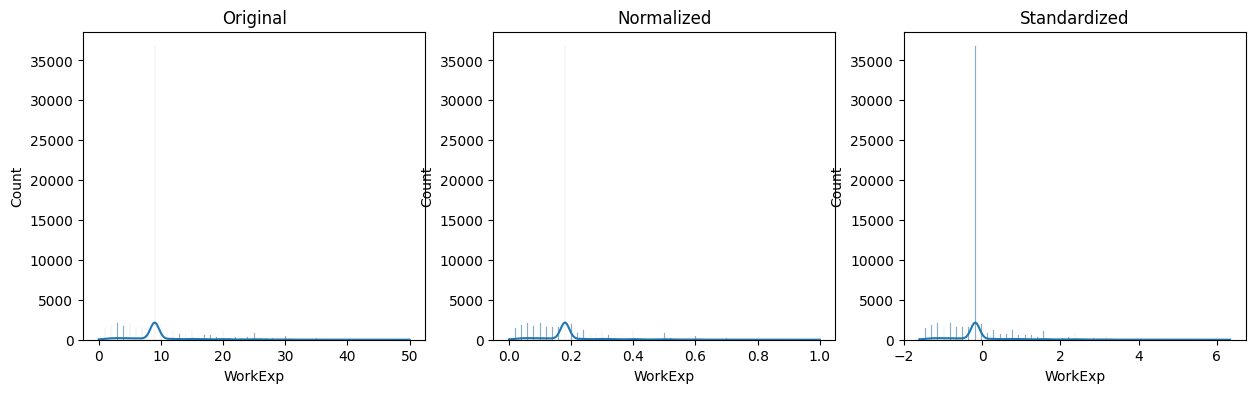

In [ ]:
#Começando pela WorkExp

col = "WorkExp" #aqui apenas definimos qual a coluna em que queremos fazer o teste

fig, axes = plt.subplots(1,3, figsize=(15,4))

#Criamos então um gráfico original, com as variáveis originais (sem alteração)
sns.histplot(data[col], kde=True, ax=axes[0])
axes[0].set_title("Original")

#Depois criamos um gráfico com a variável normalizada, ou seja, com os valores transformados para um intervalo entre 0 e 1
sns.histplot(data_normalized[col], kde=True, ax=axes[1])
axes[1].set_title("Normalized")

#E por fim, criamos um gráfico com a variável padronizada, ou seja, com os valores transformados para terem média 0 e desvio padrão 1
sns.histplot(data_standardized[col], kde=True, ax=axes[2])
axes[2].set_title("Standardized")

plt.show()


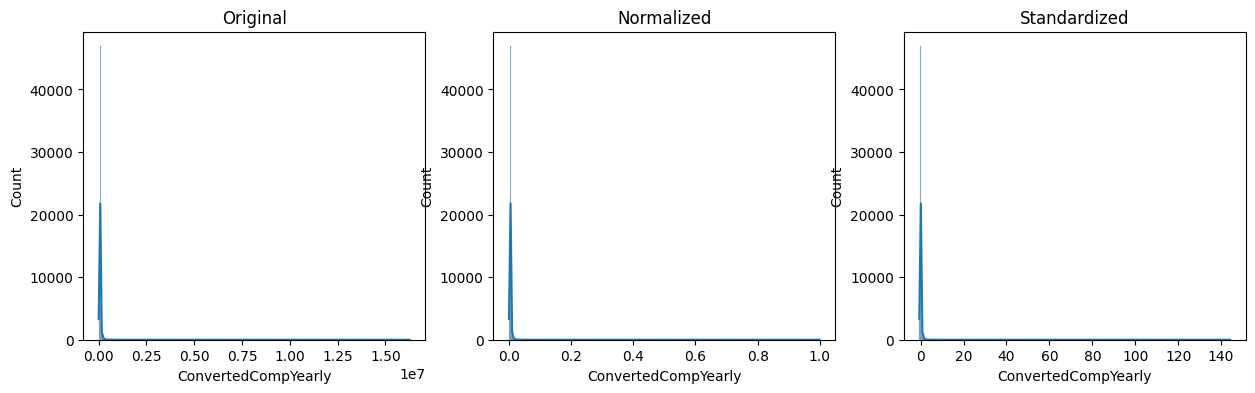

In [ ]:
col = "ConvertedCompYearly" #aqui apenas definimos qual a coluna em que queremos fazer o teste

fig, axes = plt.subplots(1,3, figsize=(15,4))

#Criamos então um gráfico original, com as variáveis originais (sem alteração)
sns.histplot(data[col], kde=True, ax=axes[0])
axes[0].set_title("Original")

#Depois criamos um gráfico com a variável normalizada, ou seja, com os valores transformados para um intervalo entre 0 e 1
sns.histplot(data_normalized[col], kde=True, ax=axes[1])
axes[1].set_title("Normalized")

#E por fim, criamos um gráfico com a variável padronizada, ou seja, com os valores transformados para terem média 0 e desvio padrão 1
sns.histplot(data_standardized[col], kde=True, ax=axes[2])
axes[2].set_title("Standardized")

plt.show()

In [ ]:
print(data.columns.tolist()) # verificamos só quais as nossas colunas numéricas

['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'Age_Code']


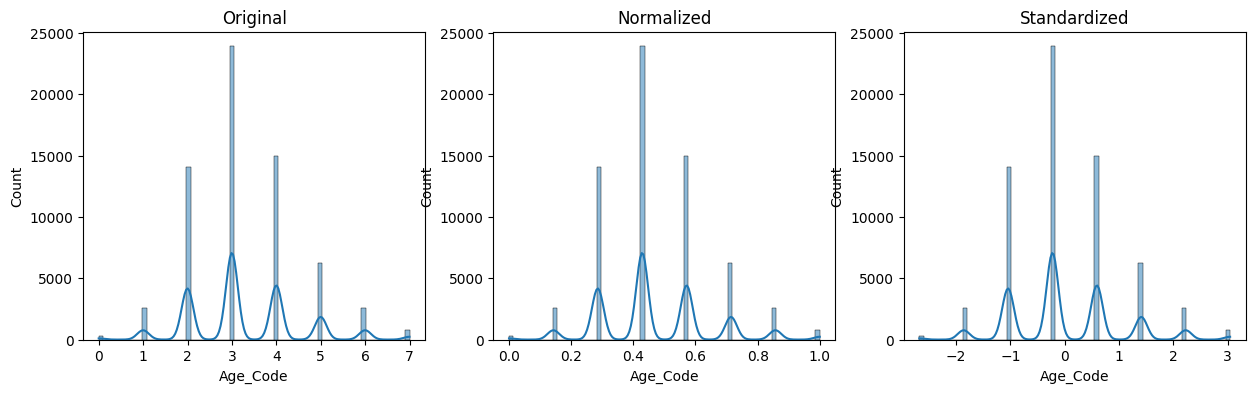

In [ ]:
col = "Age_Code" #aqui apenas definimos qual a coluna em que queremos fazer o teste

fig, axes = plt.subplots(1,3, figsize=(15,4))

#Criamos então um gráfico original, com as variáveis originais (sem alteração)
sns.histplot(data[col], kde=True, ax=axes[0])
axes[0].set_title("Original")

#Depois criamos um gráfico com a variável normalizada, ou seja, com os valores transformados para um intervalo entre 0 e 1
sns.histplot(data_normalized[col], kde=True, ax=axes[1])
axes[1].set_title("Normalized")

#E por fim, criamos um gráfico com a variável padronizada, ou seja, com os valores transformados para terem média 0 e desvio padrão 1
sns.histplot(data_standardized[col], kde=True, ax=axes[2])
axes[2].set_title("Standardized")

plt.show()

In [ ]:
#Análise dos Resultados Obtidos

#A aplicação das técnicas de normalização e padronização permitiu observar o impacto destas transformações nas variáveis WorkExp, ConvertedCompYearly e Age_Code.

#Então na primeira variável, conseguimos perceber que a distribuição original apresenta uma concentração significativa em torno de valores intermédios, com alguma 
#assimetria à direita. Depois de efetuarmos o processo de normalização, os valores foram modificados para o intervalo entre 0 e 1, mas mantendo a forma da distribuição.
#Já na parte da padronização os valores foram transformados para terem média 0 e desvio padrão 1, o que resultou numa distribuição mais centrada, numa disperção mais evidente 
#e com uma escala diferente, mas ainda assim mantendo a forma geral da distribuição.

#Passando para os testes efetuados na segunda variável, vemos que o resultado foi uma distribuição fortemente assimétrica com uma grande concentração de valores baixos e onde 
#os extremos são bastante elevados. VErificamos exatamente os mesmos resultdos tanto na normalização como na padronização, ou seja, estas técncias que aplicamos não eliminam os 
#outliers, apenas a escala é que é modificada (Por exemplo: na normalização os valores passaram a ser de 0 a 1 e na padronização os valores passaram a ter média 0 e desvio padrão 1, mas os outliers continuam lá).

#Por último, o último teste que foi feito em relação ao Age_Code, vemos uns resultados interessantes. Possuímos uma distribuição discreta, onde os picos são bem definidos de acordo com as categorias etárias. 
#Depois de efetuado o processo de normalização e padronização, a estrutura discreta mantém-se, apenas as escalas é que são alteradas. 

#Concluímos então que tanto a normalização como a padronização não modificam a forma das distribuições, apenas modificam a escala. Estas técnicas são bastante úteis para que seja possível e viável 
#comparar as variáveis entre si. Não resolvendo problemas como assimetria ou a presença de outliers.